### Create the CartPole environment

In [ ]:
import pandas as pd
import numpy as np
import gym
env = gym.make('CartPole-v0')

### Setup R packages

In [2]:
from cxrl.lib.r_to_py import setup_R
setup_R()

[]


### A sample policy for Cartpole

In [3]:
def policy(state):
    x0 = state[0]/2.4
    x2 = state[2]/2.095
    if x0*0.4+x2*0.6>=0:
        return 1
    else:
        return 0

### Infer the global causal graph from episodes

In [22]:
from cxrl.lib.xrl import XRL
# names for interpretable representations(states and actions)
feature_names = ['cart_position', 'cart_velocity', 'pole_angle', 'pole_velocity', 'push']
xrl = XRL(env, pi=policy, repr_names=feature_names, verbose=True, repr_integration=False, nepisodes=200)

experience size= 6074
 causes: ['cart_position', 'cart_velocity'] -> cart_position
 causes: ['cart_velocity', 'push'] -> cart_velocity
 causes: ['pole_angle', 'pole_velocity'] -> pole_angle
 causes: ['cart_velocity', 'pole_angle', 'pole_velocity', 'push'] -> pole_velocity
 causes: ['cart_position', 'pole_angle', 'push'] -> push
BART SLA elapsed time: 0.0 seconds


### Infer the local causal graph from given state (state at game step 500)

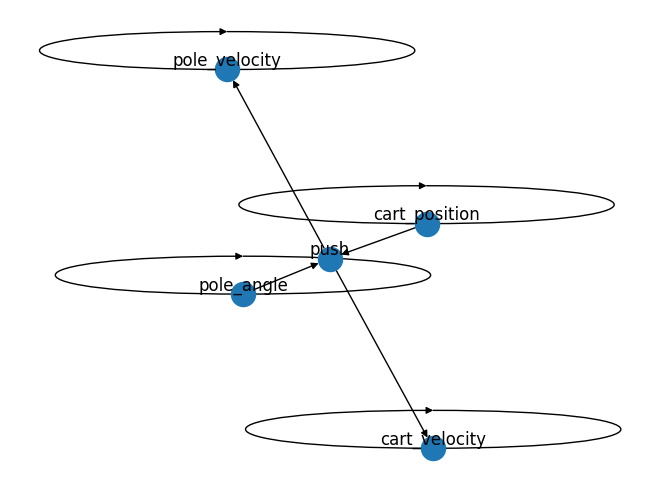

In [25]:
step = 500
# tuple of states, actions, rewards, states_new
states, actions, rewards, states_new = xrl.replay_buffer

from cxrl.lib.utils import convert_and_expand
states = convert_and_expand(states).astype(float)
actions = convert_and_expand(actions).astype(float)

replay = pd.DataFrame(np.concatenate((states, actions), axis=1), columns=feature_names)

query = replay[step:step+1]
localG = xrl.local_causal_network(query)
xrl.render_network(localG)